# Data Formatting

In [ ]:
!pip install adjustText

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import cvxpy as cp
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import statsmodels.api as sm
import geopandas as gpd

from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, check_array,check_is_fitted)
from statsmodels.tsa.arima_process import ArmaProcess
from google.colab import files
from google.colab import drive
drive.mount('/mnt/drive', force_remount=True)
from matplotlib import pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import TwoSlopeNorm
from cycler import cycler
from collections import defaultdict
from adjustText import adjust_text
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

Mounted at /mnt/drive


In [ ]:
df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()

df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

In [ ]:
# CSV
df_fil_ct = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all.csv").T.iloc[1:]
df_fil_zip = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_zip.csv").T.iloc[1:]
df_combined = pd.concat([df_fil_ct, df_fil_zip])

df_combined = df_combined.reset_index()
df_combined = df_combined.rename(columns={'index': 'disaster_GEOID'})
df_combined[['disasterNumber', 'GEOID']] = df_combined['disaster_GEOID'].str.split('_', expand=True)

df_combined['disasterNumber'] = df_combined['disasterNumber'].astype(str)
df_combined['GEOID'] = df_combined['GEOID'].astype(str)
df_combined = df_combined.drop(columns=['disaster_GEOID'])

new_columns = [str(i) for i in range(-12, 13)] + ['disasterNumber'] + ['GEOID']   # -12〜12
df_combined.columns = new_columns

# combine GEOID-city
geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()
df_combined['GEOID'] = df_combined['GEOID'].astype(str)
geo_city_df['GEOID'] = geo_city_df['GEOID'].astype(str)

# Merge
df_combined_with_city = df_combined.merge(
    geo_city_df,
    on='GEOID',
    how='left'
)

disaster_type_dict = {
    "4755": "Severe Storm (2023)",
    "4729": "Severe Storm (2023/06)",
    "4735": "Severe Storm (2023/07)",
    "4665": "Flood (2022)",
    "4651": "Snowstorm (2022)",
    "4645": "Severe Storm (2022)",
    "4637": "Tornado (2022)",
    "4601": "Tornado (2021)",
    "4594": "Severe Ice Storm (2021)",
    "4751": "Severe Storm (2021)",
    "4734": "Hurricane (2023)",
    "4712": "Severe Storm (2023)",
    "4709": "Flood (2023)",
    "4644": "Severe Storm (2022)",
    "4602": "Severe Ice Storm (2021)"
}

df_combined_with_city["disaster_type"] = df_combined_with_city["disasterNumber"].astype(str).map(disaster_type_dict)


# Map

city_att12 (sample):
Boston, MA 0.00654198948194079
Fort Lauderdale, FL -0.012796959829751112
Gainesville, FL -0.024513697355485236
Jacksonville, FL -0.020700685774539592
Memphis, TN -0.0006627813394582584
Nashville, TN -0.009292186887065306
New York, NY -0.0024648774434603716
Richmond, VA 0.022960284510420353
St Louis, MO -0.020051575143377704
Tampa, FL -0.022521333688190547


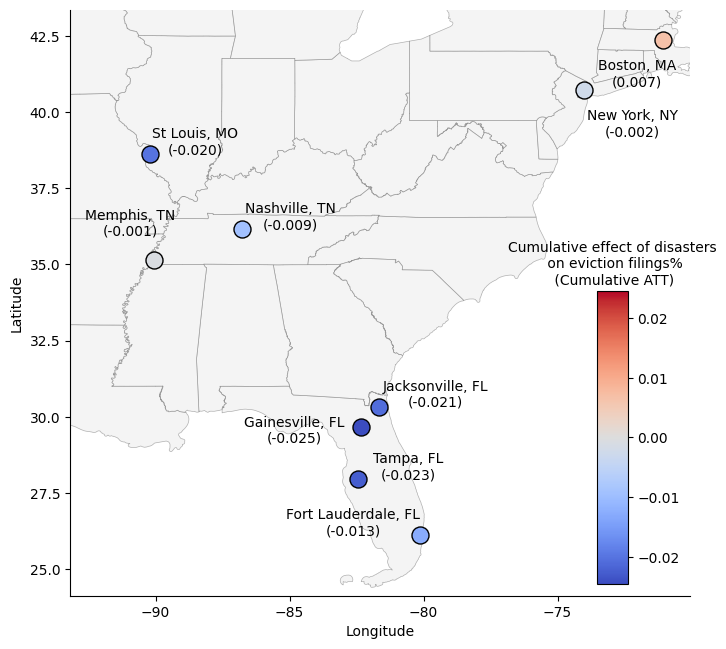

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_combined_with_city["disaster"] = df_combined_with_city["disasterNumber"].astype(str)
df_combined_with_city["GEOID"] = df_combined_with_city["GEOID"].astype(str)
df_combined_with_city["city"] = df_combined_with_city["city"].astype(str)

# --- City coordinate ---
city_coords = {
    "New York, NY": (40.7128, -74.0060),
    "Boston, MA": (42.3601, -71.0589),
    "Fort Lauderdale, FL": (26.1224, -80.1373),
    "Gainesville, FL": (29.6516, -82.3248),
    "Jacksonville, FL": (30.3322, -81.6557),
    "Memphis, TN": (35.1495, -90.0490),
    "Nashville, TN": (36.1627, -86.7816),
    # "Richmond, VA": (37.5407, -77.4360),
    "St Louis, MO": (38.6270, -90.1994),
    "Tampa, FL": (27.9506, -82.4572),
}

states = gpd.read_file("/mnt/drive/MyDrive/Colab_data/tl_2022_us_state/tl_2022_us_state.shp")

# --- Average cum ATT ---
city_att12 = {}
grouped = df_combined_with_city.groupby("city")

for city, dfc in grouped:
    if "12" in dfc.columns:
        city_att12[city] = dfc["12"].mean()

print("city_att12 (sample):")
for k, v in list(city_att12.items())[:10]:
    print(k, v)

fig, ax = plt.subplots(figsize=(8,8))

# base map
states.plot(ax=ax, color='#eeeeee', edgecolor='gray', linewidth=0.5, alpha=0.6)

# Area
lats = [lat for lat, lon in city_coords.values()]
lons = [lon for lat, lon in city_coords.values()]
ax.set_xlim(min(lons) - 3, max(lons) + 1)
ax.set_ylim(min(lats) - 2, max(lats) + 1)

# Color map
values = np.array([city_att12.get(city, np.nan) for city in city_coords.keys()])
valid_values = values[~np.isnan(values)]
if len(valid_values) == 0:
    raise ValueError("No cum att")

abs_max = max(abs(np.nanmin(valid_values)), abs(np.nanmax(valid_values)))
norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
cmap = colormaps.get_cmap('coolwarm')


# Label position
manual_offsets = {
    "New York, NY": (0, -1.5),
    "Boston, MA": (-2.5, -1.5),
    "Fort Lauderdale, FL": (-5, 0),
    "Gainesville, FL": (-4.5, -0.5),
    "Jacksonville, FL": (-2, 0),
    "Memphis, TN": (-2.7, 0.8),
    "Nashville, TN": (0, 0),
    "Richmond, VA": (-2.2, 0.8),
    "St Louis, MO": (-1, 0),
    "Tampa, FL": (0.5, 0),
}

# --- Plot ---
texts = []
x_vals = []
y_vals = []
for city, (lat, lon) in city_coords.items():
    val = city_att12.get(city, np.nan)
    if np.isnan(val):
        continue

    ax.scatter(lon, lat, s=150, color=cmap(norm(val)), edgecolor='k', alpha=1)

    dx, dy = manual_offsets.get(city, (0, 0))
    txt = ax.text(lon + dx, lat + dy, f"{city}\n({val:.3f})", fontsize=10)
    texts.append(txt)
    x_vals.append(lon)
    y_vals.append(lat)

adjust_text(
    texts,
    x=x_vals,
    y=y_vals,
    only_move='texts',
    force_text=(0, 0),
    autoalign=True
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(valid_values)
cax = inset_axes(
    ax,
    width="5%",
    height="50%",
    loc="lower right",
    bbox_to_anchor=(-0.1, 0.02, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)

cbar = plt.colorbar(
    sm,
    cax=cax,
    orientation='vertical'
)

cbar.ax.set_title("Cumulative effect of disasters\n on eviction filings%\n (Cumulative ATT)", fontsize=10, pad=5)

ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("figure.png", dpi=200)
plt.show()
from google.colab import files
files.download("figure.png")

# Line Graph

## With Filter

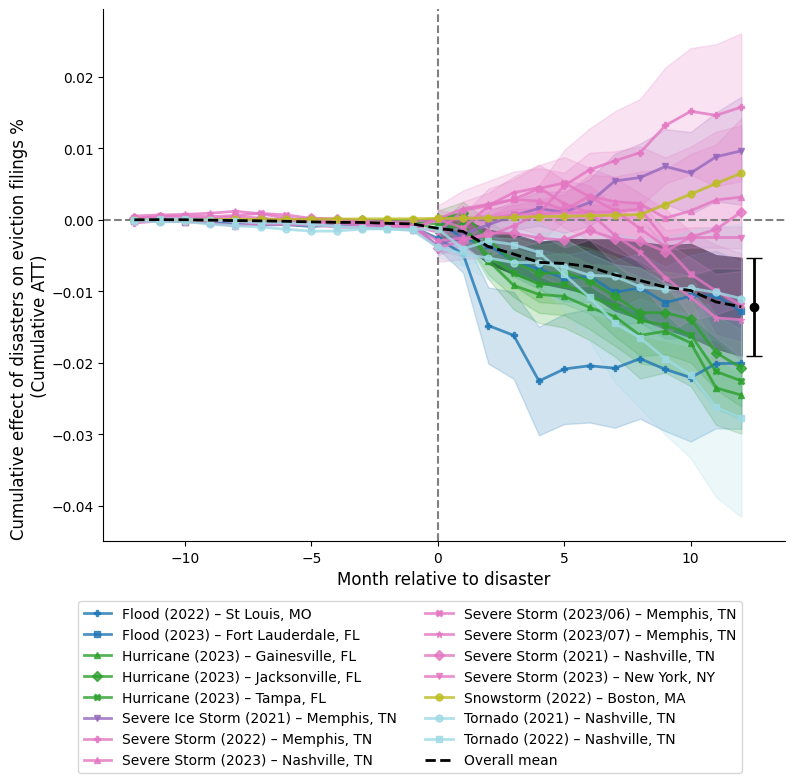

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# ==============================
# 0. Load placebo summary
# ==============================
save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"
placebo_summary_df = pd.read_csv(save_dir + "placebo_summary_df_all.csv")

# ------------------------------
# disaster SE
# ------------------------------
se_path = {}
for _, row in placebo_summary_df.iterrows():
    if pd.notna(row["disaster_id"]):
        did = str(int(float(row["disaster_id"])))
        se_path[did] = pd.Series({t: row[f"se_t{t}"] for t in range(0, 13)})

# ------------------------------
# overall SE<-disaster ID is NaN
# ------------------------------
overall_row = placebo_summary_df[
    placebo_summary_df["disaster_id"].isna()
].iloc[0]

overall_se = np.array([overall_row[f"se_t{t}"] for t in range(0, 13)])

# ==============================
# 1. Long format
# ==============================
month_cols = [str(i) for i in range(-12, 13)]

df_long = df_combined_with_city.melt(
    id_vars=["disasterNumber", "GEOID", "city"],
    value_vars=month_cols,
    var_name="month",
    value_name="cum_att"
)

df_long["month"] = df_long["month"].astype(int)
df_long = df_long[df_long["city"] != "Richmond, VA"].copy()

df_long["disaster_type"] = df_long["disasterNumber"].astype(str).map(disaster_type_dict)
df_long["disaster_type_short"] = (
    df_long["disaster_type"].str.split("(", n=1).str[0].str.strip()
)

# ==============================
# 2. Series
# ==============================
cum_att_by_city_disaster = defaultdict(list)

for (city, disaster_num, dtype_short, geo), group in df_long.groupby(
    ["city", "disasterNumber", "disaster_type_short", "GEOID"]
):
    s = pd.Series(group["cum_att"].values, index=group["month"].values)
    cum_att_by_city_disaster[(city, disaster_num, dtype_short)].append(s)

def average_series(series_list):
    df = pd.concat(series_list, axis=1)
    return df.mean(axis=1)

# ==============================
# 3. Overall mean
# ==============================
all_series = [
    s for series_list in cum_att_by_city_disaster.values()
    for s in series_list
]

overall_mean = average_series(all_series).loc[range(-12, 13)]

# ==============================
# 4. Order (sorted_keys)
# ==============================
cum_t12_mean = {
    key: np.mean([s.loc[12] for s in series_list if 12 in s.index])
    for key, series_list in cum_att_by_city_disaster.items()
    if any(12 in s.index for s in series_list)
}

disaster_type_order = sorted(df_long["disaster_type_short"].unique())

sorted_keys = sorted(
    cum_t12_mean.keys(),
    key=lambda k: (
        disaster_type_order.index(k[2]),
        int(k[1]),
        k[0]
    )
)

# ==============================
# 5. Plot
# ==============================
fig, ax = plt.subplots(figsize=(8, 9))

# ---- 色設定 ----
disaster_types_short = sorted(df_long["disaster_type_short"].dropna().unique())
cmap = matplotlib.colormaps.get_cmap("tab20").resampled(len(disaster_types_short))
color_dict_short = {d: cmap(i) for i, d in enumerate(disaster_types_short)}

# ---- marker設定 ----
city_disaster_pairs = sorted({(k[0], k[1]) for k in cum_att_by_city_disaster.keys()})
marker_list = ["o", "s", "^", "D", "v", "P", "X", "*"]
marker_dict = {
    pair: marker_list[i % len(marker_list)]
    for i, pair in enumerate(city_disaster_pairs)
}

# ------------------------------
# Individual lines (sorted)
# ------------------------------
for key in sorted_keys:
    city, disaster_num, dtype_short = key
    series_list = cum_att_by_city_disaster[key]
    mean_series = average_series(series_list)

    disaster_label = disaster_type_dict.get(str(disaster_num), str(disaster_num))

    ax.plot(
        mean_series.index,
        mean_series,
        color=color_dict_short[dtype_short],
        linewidth=2,
        alpha=0.8,
        marker=marker_dict[(city, disaster_num)],
        markersize=5,
        label=f"{disaster_label} – {city}",
        zorder=3
    )

    # ---- CI ----
    did = str(disaster_num)
    if did in se_path:
        ci_index = [t for t in mean_series.index if 0 <= t <= 12]
        if len(ci_index) > 0:
            se_vals = se_path[did].loc[ci_index] * 1.96
            ax.fill_between(
                ci_index,
                mean_series.loc[ci_index] - se_vals,
                mean_series.loc[ci_index] + se_vals,
                color=color_dict_short[dtype_short],
                alpha=0.2,
                zorder=1
            )

# ------------------------------
# Overall mean
# ------------------------------
ax.plot(
    overall_mean.index,
    overall_mean,
    linestyle="--",
    color="black",
    linewidth=2,
    label="Overall mean",
    zorder=4
)

# ------------------------------
# Overall CI（legendに入れない）
# ------------------------------
t_vals = np.arange(0, 13)

ax.fill_between(
    t_vals,
    overall_mean.loc[t_vals] - overall_se * 1.96,
    overall_mean.loc[t_vals] + overall_se * 1.96,
    color="black",
    alpha=1,
    zorder=0
)

# ---- Error bar ----
t12 = 12
offset = 0.5
t12_offset = t12 + offset

# t=12 error bar
y12 = overall_mean.loc[12]

se12 = overall_se[12]
yerr12 = se12 * 1.96

ax.errorbar(
    t12_offset,
    y12,
    yerr=yerr12,
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=2,
    capsize=6,
    zorder=5
)


# ------------------------------
# Decoration
# ------------------------------
ax.axhline(0, ls="--", color="gray")
ax.axvline(0, ls="--", color="gray")

ax.set_xlabel("Month relative to disaster", fontsize=12)
ax.set_ylabel(
    "Cumulative effect of disasters on eviction filings %\n (Cumulative ATT)",
    fontsize=12
)
ax.yaxis.set_label_coords(-0.08, 0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ------------------------------
# Legend
# ------------------------------
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.45, -0.1),
    ncol=2,
    fontsize=10
)

plt.tight_layout(rect=[0, 0.1, 1, 1])


plt.savefig("figure.png", dpi=200)
plt.show()
from google.colab import files
files.download("figure.png")

In [ ]:
import pandas as pd
import numpy as np

# ==============================
# Helper
# ==============================
def average_series(series_list):
    df = pd.concat(series_list, axis=1)
    return df.mean(axis=1)

# ==============================
# Disaster-wise cumulative ATT (t=12)
# ==============================
disaster_stats = []

for (city, disaster_num, dtype_short), series_list in cum_att_by_city_disaster.items():

    mean_series = average_series(series_list)

    if 12 not in mean_series.index:
        continue

    did = str(disaster_num)
    value = mean_series.loc[12]

    # ---- CI（disaster別 placebo SE）----
    if did in se_path and 12 in se_path[did].index:
        se12 = se_path[did].loc[12]
        ci_low = value - 1.96 * se12
        ci_up  = value + 1.96 * se12
    else:
        ci_low = np.nan
        ci_up  = np.nan

    disaster_stats.append({
        "disaster_id": did,
        "city": city,
        "disaster_type_short": dtype_short,
        "value_t12": value,
        "ci_lower_t12": ci_low,
        "ci_upper_t12": ci_up
    })

disaster_stats_df = pd.DataFrame(disaster_stats)

# ==============================
# Overall mean (t=12)
# ==============================
overall_row = placebo_summary_df[
    placebo_summary_df["disaster_id"].isna()
].iloc[0]

y12 = overall_mean.loc[12]
se12_overall = overall_row["se_t12"]

ci_low_overall = y12 - 1.96 * se12_overall
ci_up_overall  = y12 + 1.96 * se12_overall

overall_stats_df = pd.DataFrame([{
    "disaster_id": "Overall",
    "city": "",
    "disaster_type_short": "Overall mean",
    "value_t12": y12,
    "ci_lower_t12": ci_low_overall,
    "ci_upper_t12": ci_up_overall
}])

# ==============================
# Combine
# ==============================
t12_stats_df = pd.concat(
    [disaster_stats_df, overall_stats_df],
    ignore_index=True
)

t12_stats_df


,disaster_id,city,disaster_type_short,value_t12,ci_lower_t12,ci_upper_t12
0,4651,"Boston, MA",Snowstorm,0.006542,0.006542,0.006542
1,4709,"Fort Lauderdale, FL",Flood,-0.012797,-0.019691,-0.005903
2,4734,"Gainesville, FL",Hurricane,-0.024514,-0.029919,-0.019108
3,4734,"Jacksonville, FL",Hurricane,-0.020701,-0.026106,-0.015295
4,4594,"Memphis, TN",Severe Ice Storm,0.009671,0.002125,0.017217
5,4645,"Memphis, TN",Severe Storm,0.015779,0.005444,0.026115
6,4729,"Memphis, TN",Severe Storm,-0.011958,-0.019230,-0.004685
7,4735,"Memphis, TN",Severe Storm,-0.013974,-0.020803,-0.007144
8,4601,"Nashville, TN",Tornado,-0.011006,-0.021459,-0.000552
9,4637,"Nashville, TN",Tornado,-0.027770,-0.041561,-0.013978
